In [84]:
import os 
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

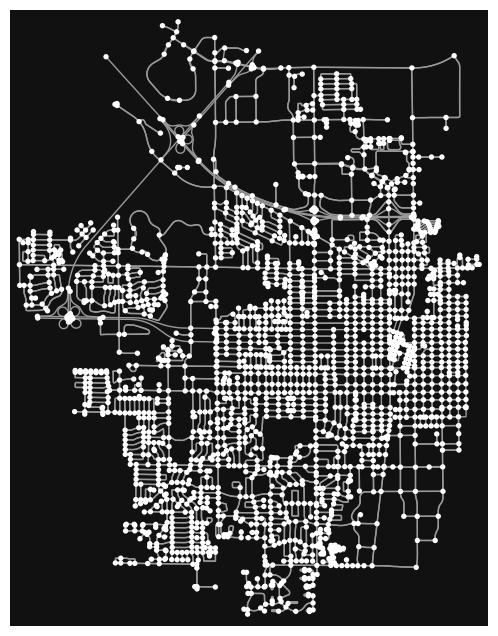

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [85]:
import osmnx as ox

## IMPORT CITY
city = ox.graph_from_place('Champaign, IL, USA', network_type='drive')

ox.plot_graph(city)

In [86]:
import networkx as nx
import numpy as np

## ADDING EDGE PROPERTIES
city = ox.speed.add_edge_speeds(city)
city = ox.speed.add_edge_travel_times(city)

## GENERATING IMPORTANT INFO
indexes = {node: i for i, node in enumerate(city.nodes)}
travel_times_dict = nx.get_edge_attributes(city, 'travel_time')

## STARTING AND ENDING NODES
str_address = '1008 S 4th St, Champaign, IL'
end_address = '2610 N Prospect Ave, Champaign, IL'

from utils import node_from_address, get_unique_path

starting_node = node_from_address(city, str_address)
final_node = node_from_address(city, end_address)

In [5]:
## FILTERING OUT UNDESIRABLE NODES, GENERATING INCIDENCE MATRIX

banned_coords = [(40.130902, -88.243662), 
                (40.130462, -88.238855), 
                (40.132660, -88.243546),
                (40.132989, -88.257875),
                (40.127197, -88.245215)]

banned_nodes = [ox.nearest_nodes(city, lon, lat) for lat, lon in banned_coords]

#banned_nodes = []
banned_edges = []
banned_edges_idx = []

edges = list(city.edges)

n_points = len(city.nodes)
n_edges = len(city.edges)

A = np.zeros((n_points, n_edges))

for i, (u, v, k) in enumerate(edges):
    if u in banned_nodes or v in banned_nodes:
        banned_edges += [(u, v, k)]
        banned_edges_idx += [i]
        pass

    A[indexes[u]][i] = -1
    A[indexes[v]][i] = 1

[(37945287, 38157261, 0), (37945299, 38092893, 0), (37952399, 37977105, 0), (37977105, 37952399, 0), (37977105, 37977147, 0), (37977105, 38092901, 0), (37977105, 38157261, 0), (37977147, 37977105, 0), (37982955, 38128444, 0), (37999267, 38157261, 0), (37999274, 38128444, 0), (38027612, 38128444, 0), (38092893, 38092898, 0), (38092893, 37945299, 0), (38092893, 7413868599, 0), (38092898, 38092893, 0), (38092901, 37977105, 0), (38128444, 38027612, 0), (38128444, 37999274, 0), (38157261, 37999267, 0), (38157261, 37977105, 0), (38157261, 37945287, 0), (5680617585, 5680618729, 0), (5680617585, 5680618729, 1), (5680618729, 6119772436, 0), (7413868599, 38092893, 0)]


In [93]:
## LINEAR PROGRAM LOGIC
import gurobipy as gp
from gurobipy import GRB

b = np.zeros(n_points)

b[indexes[starting_node]] = -1
b[indexes[final_node]] = 1

f = np.zeros(n_edges)

m = gp.Model("lp")

m.Params.LogToConsole = 0
m.Params.Method = 0

f = m.addMVar(shape=n_edges, vtype=GRB.INTEGER, lb=0, name="")

weights = [travel_time for edge, travel_time in travel_times_dict.items()]

m.addConstr(A@f==b)
obj = np.array(weights)@f
m.setObjective(obj, GRB.MINIMIZE)

Path length: 7m23s, 442.7s


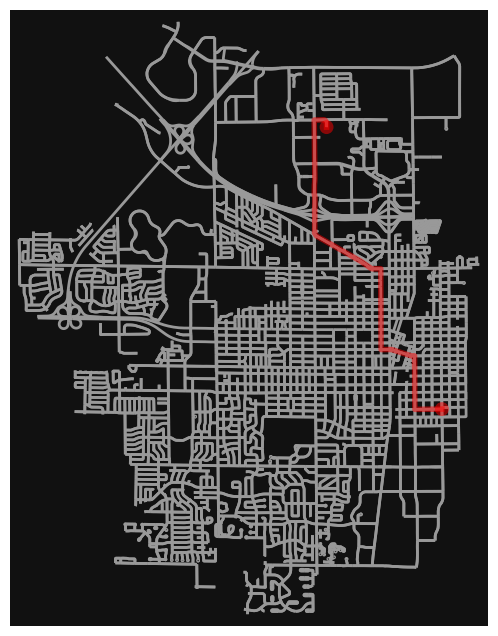

Path length: 7m23s, 442.7s


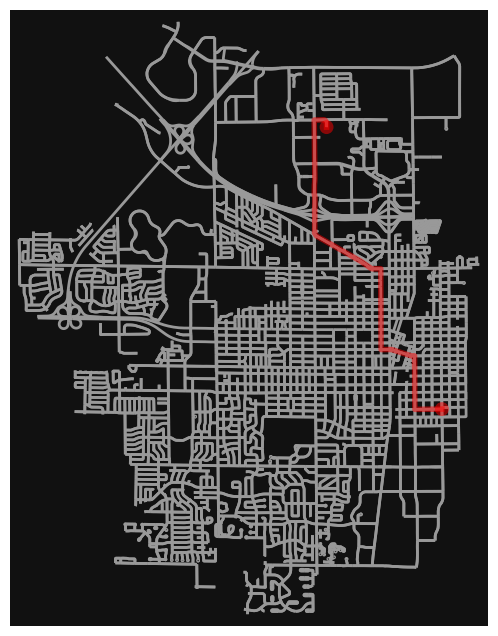

Path length: 7m23s, 442.7s


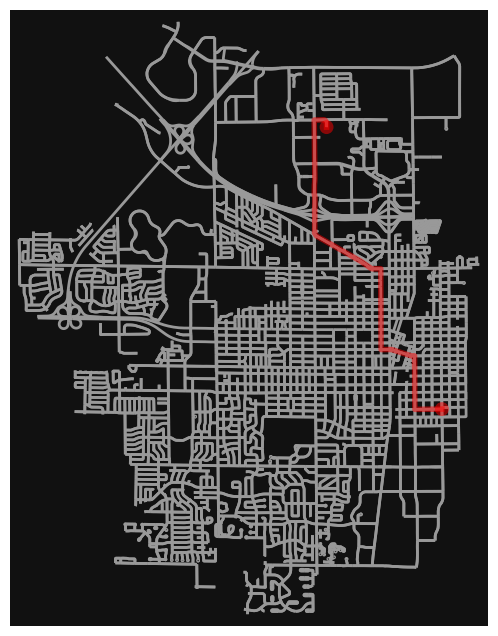

Path length: 7m35s, 454.9s


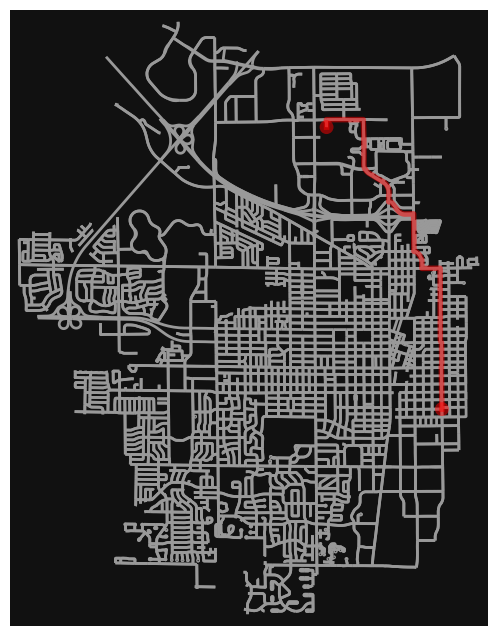

Path length: 10m18s, 618.0s


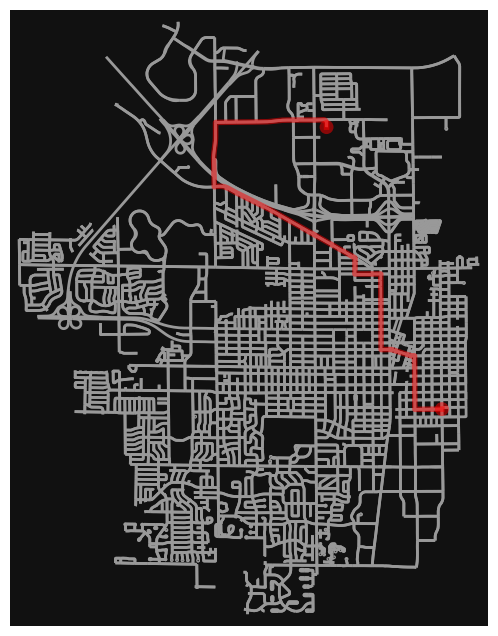

In [94]:
## TESTING FOR DIFFERENT BUDGETS
max_budget = 5
for budget in range(max_budget):
    m.addConstr(gp.quicksum(f[i] for i in banned_edges_idx) <= ((max_budget-1)-budget)*2)

    m.optimize()

    flows = m.getAttr("X", m.getVars())

    objval = m.ObjVal

    print(f'Path length: {int(objval//60)}m{round(objval%60)}s, {objval}s')

    flowed_edges_idx = []
    flowed_edges = []

    for i in range(len(flows)):
        if flows[i]:
            #print(flows[i])
            flowed_edges_idx += [i]

    flowed_pts = []

    for i, (u, v, k) in enumerate(city.edges):
        if i in flowed_edges_idx:
            flowed_edges += [(u, v, k)]
            #if i in banned_edges_idx:
                #print(i, edges[i])

            for pt in (u, v):
                if pt not in flowed_pts:
                    flowed_pts += [pt]

    from utils import get_edges_and_points

    path, pts = get_edges_and_points(flowed_edges, starting_node=starting_node, final_node=final_node)

    fig, ax = ox.plot_graph_route(city, pts, node_color='w', node_edgecolor='k', node_size=0, 
                            node_zorder=3, edge_linewidth=2)

In [12]:
for current_edge in flowed_edges:
    matching_edges = [edge for edge in flowed_edges if edge[0] == current_edge[1]]
    if len(matching_edges) >= 2: print(current_edge)